<a href="https://colab.research.google.com/github/VLGen/---AI--/blob/main/AI_%D0%BD%D0%B0%D1%81%D1%82%D0%B0%D0%B2%D0%BD%D0%B8%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Нейро-сотрудник: “AI-наставник по обучению и структурированию знаний”

Первым делом передо мной встала задача определиться с целью создания нейро-сотрудника, то есть с его *профессией*.

Я решил отталкиваться от своих потребностей, а так как я еще учусь и в процессе мне часто необходимо разъяснение тех или иных моментов, то выбор пал на создание AI-настаника.


---



Задачи AI-наставника:

*   Конспектировать материал
*   Объяснять более простым языком (или сложным при необходимости)
*   Помогать запоминать и понимать


---


Мышление и характер:


*   Мыслит как ментор/преподаватель
*   Тон общения спокойный, дружелюбный, но не слишком мягкий
*   Ориентирован на понимание, а не заучивание
*   Структурирует информацию
*   Замечает пробелы в понимании
*   Указывает на ошибки


## Создание и обработка данных

Основа нейро-сотрудника - это база знаний, с которой он будет работать. Я решил создать и структурировать с помощью ChatGPT некоторое количество гугл-документов для дальнейшего построения графовой RAG-системы.


---


Конечно, для более масштабного и реально пригодного для обучения и бизнеса нейро-сотрудника нужна гораздо большая база знаний, чем десяток собственноручно написанных документов. Однако моя цель состоит в том, чтобы создать действительно рабочий проект, показать, какие инструменты я использовал и как именно, сделать, своего рода, макет, который может послужить фундаментом уже для настоящего рабочего нейро-сотрудника.

Сами документы выглядят так:

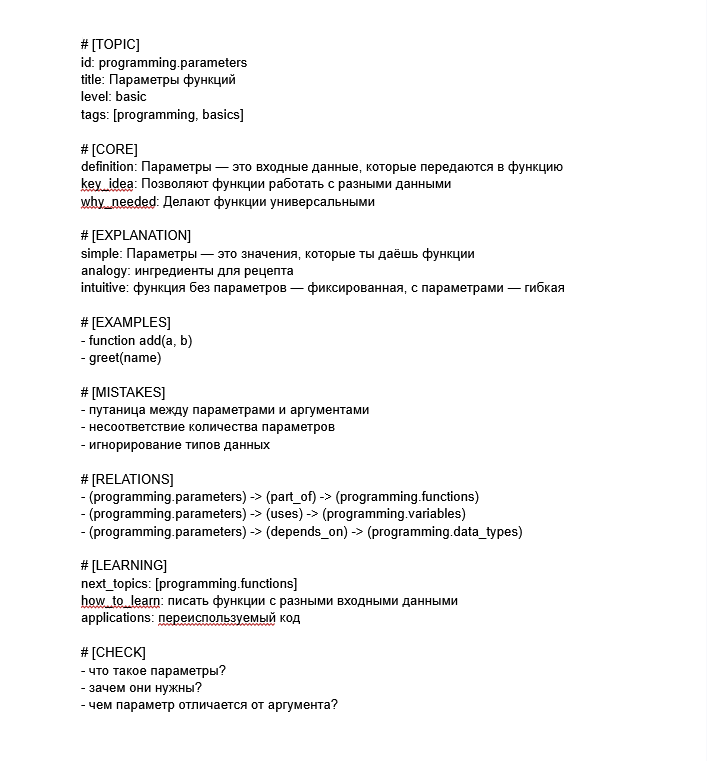

## Установка зависимостей и импорт библиотек


In [ ]:
!pip install llama-index llama-index-llms-llama-cpp llama-index-embeddings-huggingface llama-index-retrievers-bm25 huggingface-hub nest-asyncio sentence-transformers

In [ ]:
!pip install 'arize-phoenix>=4.30.2'

In [ ]:
!pip install llama-index-callbacks-arize-phoenix

In [ ]:
!pip uninstall uvicorn -y
!pip install uvicorn==0.27.1

После долгого копания с подбором всех совместимых зависимостей всё загрузилось и можно приступать к написанию самого кода.

In [ ]:
import logging
import sys
import os

import nest_asyncio
from google.colab import userdata
from google.colab import drive
import getpass

from llama_index.core import (
    Settings, SimpleDirectoryReader, VectorStoreIndex,
    PromptTemplate, get_response_synthesizer
)
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.llms.llama_cpp import LlamaCPP
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

from huggingface_hub import login

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
nest_asyncio.apply()

In [ ]:
import phoenix as px
from llama_index.core import set_global_handler

## Авторизация и добавление ключа API

#### Авторизация на HuggingFace

In [ ]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
login()

In [ ]:
# Проверка работоспособности токена
from huggingface_hub import whoami
print(whoami())

## Установка моделей

#### Основная модель

Для загрузки моделей я буду использовать `LlamaCPP`, как делал это в предыдущих уроках. Он подходит для работы с моделями GGUF формата, хорошо работает на CPU и прост в запуске.

Модель же задействую следующую: `RefalMachine/ruadapt_qwen2.5_7B_ext_u48_instruct_gguf`. Это адаптированная на русский язык версия модели `Qwen2.5-7B`. В ней был заменен токенизатор, благодаря чему возросла скорость генерации русскоязычных текстов. В лидерборде по винрейту она занимает 4 место с результатом в 81.9% (результаты на Ru-Arena-General).

In [ ]:
llm = LlamaCPP(
    model_url="https://huggingface.co/RefalMachine/ruadapt_qwen2.5_7B_ext_u48_instruct_gguf/resolve/main/Q4_K_M.gguf?download=true",
    temperature=0.2,
    max_new_tokens=256,
    context_window=2048,
    verbose=True
)

#### Модель внедрения

В качестве модели внедрения использую `cointegrated/rubert-tiny2`. Она специализирована на русском языке, имеет словарь на 83828 токенов, быстрая и небольшая, что и нужно для тренировочного проекта.

In [ ]:
embed_model = HuggingFaceEmbedding(model_name="cointegrated/rubert-tiny2")

#### Настройка окружения

In [ ]:
Settings.llm = llm
Settings.embed_model = embed_model
Settings.chunk_size = 256

## Загрузка документов

Подгружаю документы из своего гугл-диска

In [ ]:
drive.mount('/content/drive')

In [ ]:
FOLDER_PATH = '/content/drive/MyDrive/Learning'

if os.path.exists(FOLDER_PATH):
  print("Папка найдена ", FOLDER_PATH)

Для фильтрации запросов мне понадобится извлечь метаданные из документов. Фильтровать я буду просто по названию документа, которое будет указано вручную.

In [ ]:
def get_custom_metadata(filename):
    # Получаю только имя файла из полного пути
    base_name = os.path.basename(filename)
    return {"topic": base_name.split(".")[0]}

In [ ]:
# Использую SimpleDirectoryReader, так как работать нейро-сотрудник будет с уже загруженными документами
all_documents = SimpleDirectoryReader(
    input_dir=FOLDER_PATH,
    file_metadata=get_custom_metadata # Применяю функцию к каждому файлу
).load_data()

print(all_documents[0].metadata)

## Создание индекса

В качестве индекса использую обычный VectorStoreIndex. Документов у меня немного и они небольшие, поэтому использовать KnoledgeGraph было бы слишком затратно и неэффективно. Векторной базы вполне хватит для задачи такого уровня.


---

 *Скажу честно, я пытался использовать KnoledgeGraph, но это действительно оказалось слишком избыточно. Создавался он очень долго, генерация происходила также не быстро, а отличий по качеству ответов заметно не было.*

In [ ]:
index = VectorStoreIndex.from_documents(
    documents=all_documents,
    show_progress=True
)

## Запуск трассировки

In [ ]:
session = px.launch_app()
set_global_handler("arize_phoenix")

print(f"✅ Трассировка настроена. Phoenix UI: {session.url}")

## Создание Query Engine и тестовый инференс

In [ ]:
query_engine = index.as_query_engine(include_text=True, verbose=True)

In [ ]:
query = [
      "Какие бывают типы данных?",
      "Как тип данных влияет на параметры функции?",
      "Что такое алгоритмы?"
      ]

for q in query:
    print(f"Студент: {q}")
    response = query_engine.query(q)
    print(f"Наставник: {response}\n")

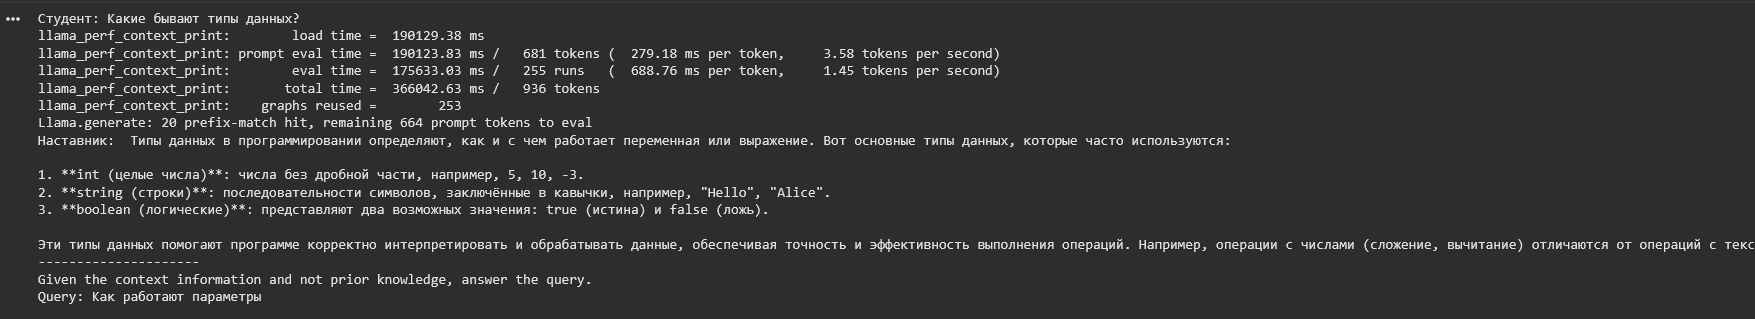

Ответы получились неплохими, не считая первого запроса. По какой-то причине в него вошли еще и изначальные инструкции, написанные в стандартном промпте. Также почему-то начал генерироваться другой вопрос.

Изначально я не ввожу никакого промпта, а делаю просто чистые тестовые запросы. По трассировке видно, что там стоит инструкция по умолчанию.

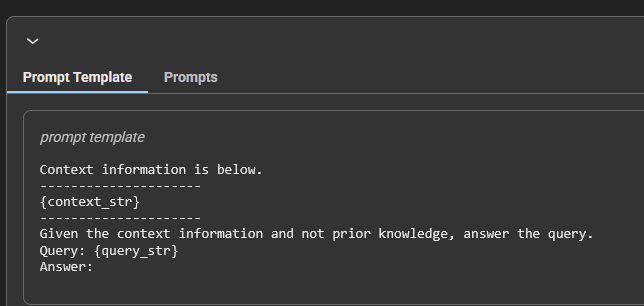

Предположительно, в первом вопросе происходит галлюцинация из-за поиска по двум файлам `file_path: /content/drive/MyDrive/Learning/Типы данных.txt` и `file_path: /content/drive/MyDrive/Learning/Параметры функций.txt`

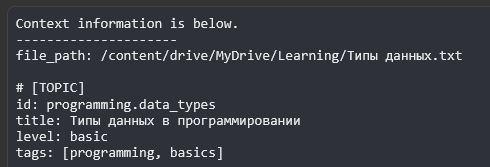

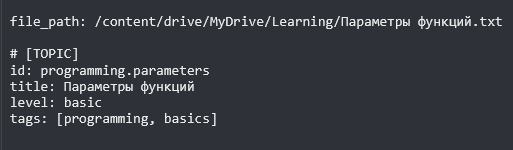

## Борьба с галлюцинациями

Далее я хочу ввести промпт, чтобы у нейро-наставника были четкие инструкции

In [ ]:
custom_prompt_str = """
Ты — AI-наставник по обучению и структурированию знаний.
Твои задачи:
- Объяснять материал простым языком или (при необходимости) более сложно.
- Помогать запоминать и понимать, а не заучивать.
- Структурировать информацию, замечать пробелы в понимании.

Характер: спокойный, дружелюбный, но требовательный. Указывай на ошибки.

Ниже приведён контекст из учебных материалов. Отвечай ТОЛЬКО на основе этого контекста и ТОЛЬКО на поставленный вопрос.
Если в контексте нет информации, необходимой для ответа, честно скажи: «Я не знаю наверняка, но могу предположить...» и кратко объясни, почему. Не придумывай факты.

Контекст:
{context_str}

Вопрос студента: {query_str}

Ответ наставника:
"""

custom_prompt = PromptTemplate(custom_prompt_str)

In [ ]:
# Создание синтезатора ответов
response_synthesizer = get_response_synthesizer(llm=llm, text_qa_template=custom_prompt)

Также хочу ввести расширенный поисковик для большей конкретизации ответа. Буду использовать Hybrid Fusion - поисковик объединяющий в себе обычный векторный поиск и BM25

In [ ]:
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.base.embeddings.base import similarity
from llama_index.core.vector_stores.types import (
    MetadataFilter,
    MetadataFilters,
    FilterOperator,
    FilterCondition
)

vector_retriever = index.as_retriever(similarity_top_k=5)
bm25_retriever = BM25Retriever.from_defaults(docstore=index.docstore, similarity_top_k=5)

def query_with_topic(query_text, topic):

    filters = MetadataFilters(
        filters=[MetadataFilter(key="topic", value=topic, operator=FilterOperator.EQ)]
    )

    # Временно подменяем векторный ретривер на новый с фильтром
    filtered_vector_retriever = index.as_retriever(
        similarity_top_k=5,
        filters=filters
    )
    fusion = QueryFusionRetriever(
        retrievers=[filtered_vector_retriever, bm25_retriever],
        similarity_top_k=5,
        mode="reciprocal_rerank"
    )
    temp_engine = RetrieverQueryEngine.from_args(
        retriever=fusion,
        response_synthesizer=response_synthesizer
    )
    return temp_engine.query(query_text)

Теперь сделаю "проблемные" запросы с этими доработками и проверю изменения.

In [ ]:
check_query = [
    "Какие бывают типы данных?",
    "Как тип данных влияет на параметры функции?",
]

for q in check_query:
    print(f"Студент: {q}")
    if q == "Какие бывают типы данных?":
        response = query_with_topic(q, "Типы данных")
    elif q == "Как тип данных влияет на параметры функции?":
        response = query_with_topic(q, "Параметры функций")
    print(f"Наставник: {response}")

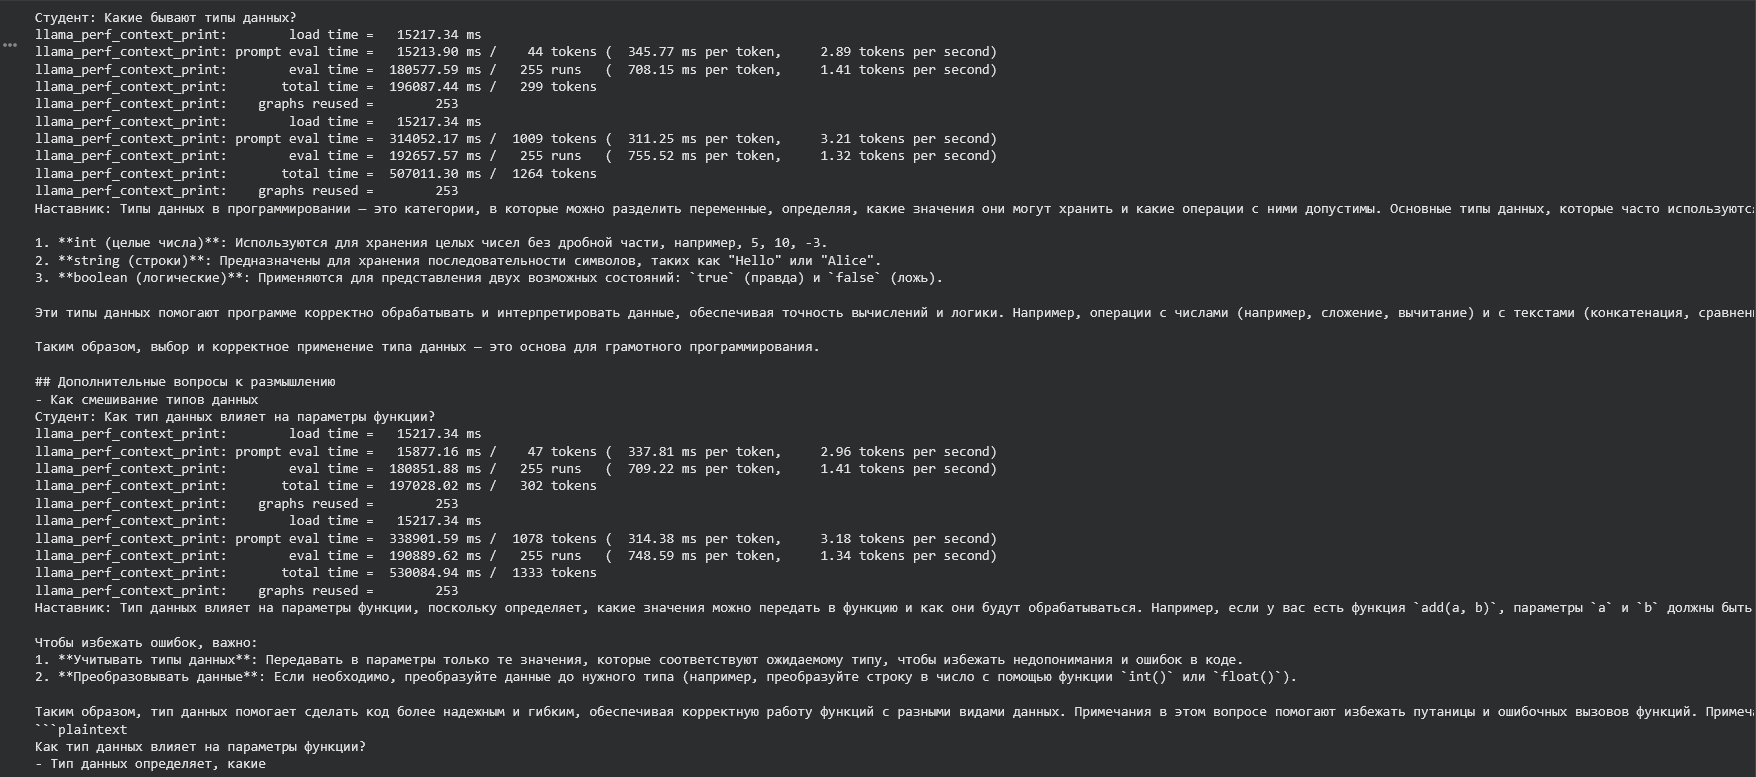

В трассировке теперь отображается промпт

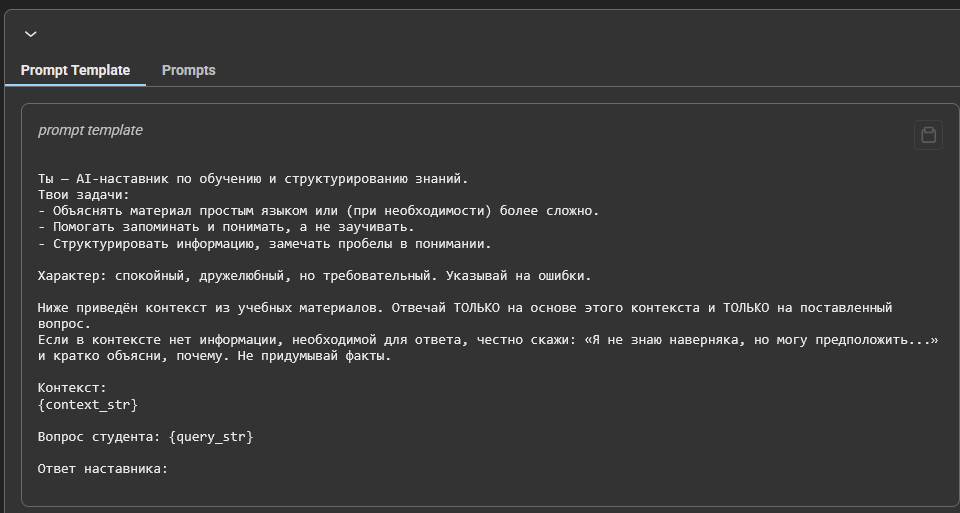

Ответ стал более полным и строгим, что мне и было нужно. Цель задачи была достигнута.


---

Подведение итогов.

Была пошагово проведена большая работа:

*   Создание и обработка документов
*   Выбор и установка основной LLM и модели внедрения
*   Создание фильтров
*   Создание векторного индекса
*   Простой тестовый инференс
*   Доработка RAG-системы, борьба с галлюцинациями